In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Reload dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                'ca', 'thal', 'target']

df = pd.read_csv(url, header=None, names=column_names)
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(), inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("✅ Data loaded! Shape:", df.shape)

✅ Data loaded! Shape: (303, 14)


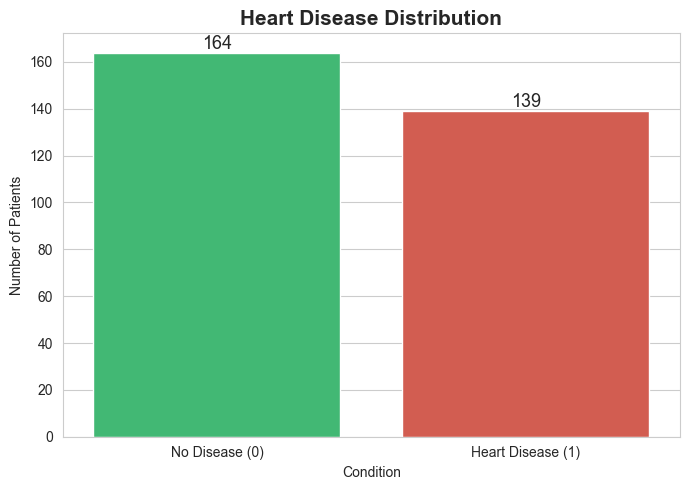

✅ Chart saved!


In [2]:
# Target distribution (Disease vs No Disease)
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='target', data=df, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
plt.title('Heart Disease Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13)
plt.tight_layout()
plt.savefig('../data/plot_target.png')
plt.show()
print("✅ Chart saved!")

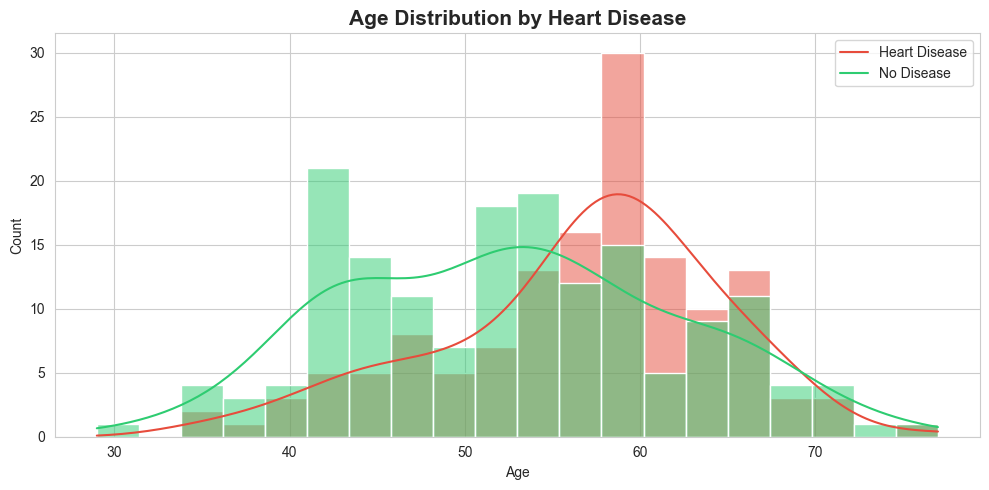

In [3]:
# Age distribution by disease
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', bins=20,
             palette=['#2ecc71', '#e74c3c'], kde=True)
plt.title('Age Distribution by Heart Disease', fontsize=15, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Heart Disease', 'No Disease'])
plt.tight_layout()
plt.savefig('../data/plot_age.png')
plt.show()

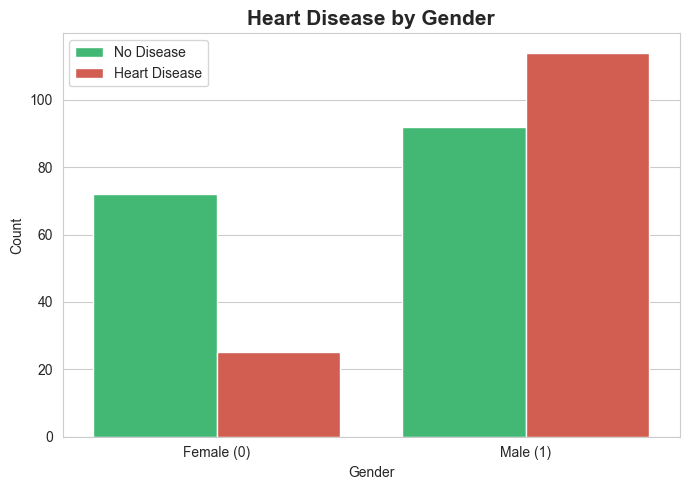

In [4]:
# Gender analysis
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='sex', hue='target', data=df,
                   palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Female (0)', 'Male (1)'])
plt.title('Heart Disease by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('../data/plot_gender.png')
plt.show()

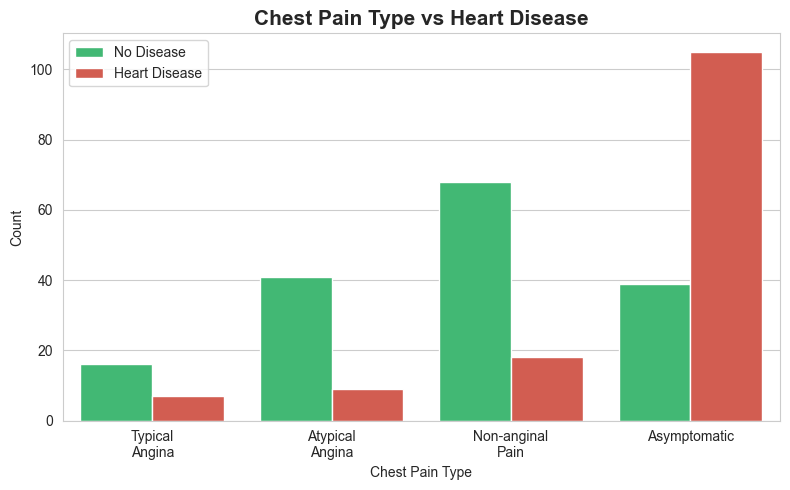

In [5]:
# Chest pain type vs disease
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='cp', hue='target', data=df,
                   palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Typical\nAngina', 'Atypical\nAngina',
                    'Non-anginal\nPain', 'Asymptomatic'])
plt.title('Chest Pain Type vs Heart Disease', fontsize=15, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('../data/plot_cp.png')
plt.show()

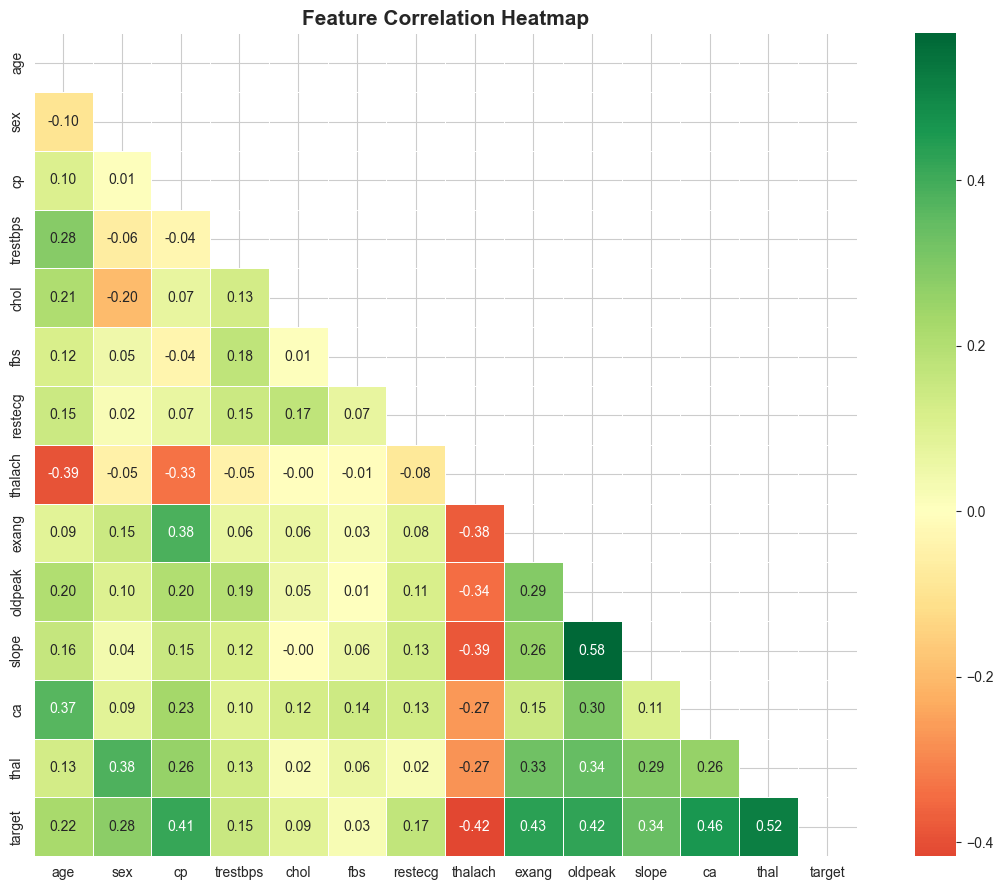

✅ Heatmap saved!


In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_heatmap.png')
plt.show()
print("✅ Heatmap saved!")

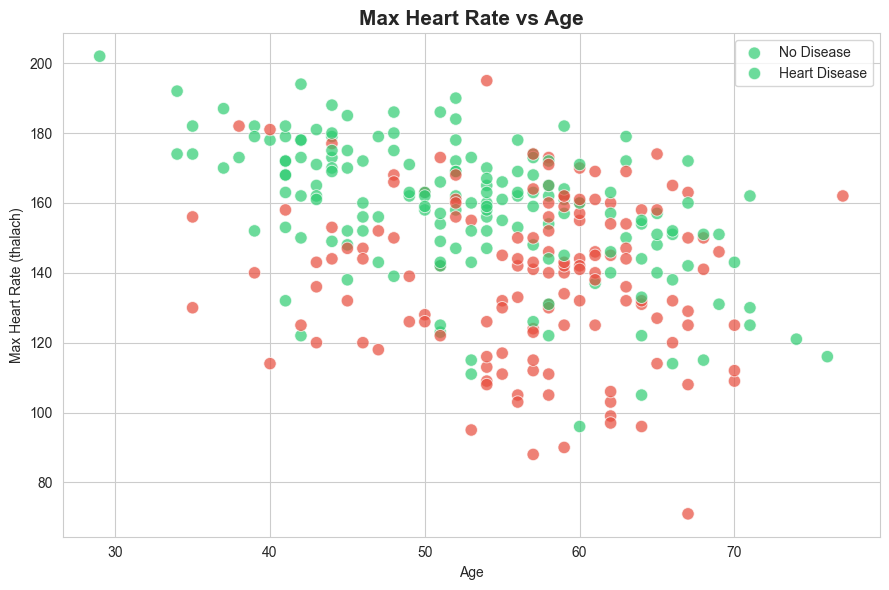

In [7]:
# Max heart rate vs age (scatter)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target',
                palette=['#2ecc71', '#e74c3c'], alpha=0.7, s=80)
plt.title('Max Heart Rate vs Age', fontsize=15, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalach)')
plt.legend(['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('../data/plot_scatter.png')
plt.show()

In [8]:
# Summary insights
print("=" * 45)
print("        KEY INSIGHTS FROM EDA")
print("=" * 45)
print(f"Total patients        : {len(df)}")
print(f"Heart disease cases   : {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"No disease cases      : {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
print(f"Average age           : {df['age'].mean():.1f} years")
print(f"Male patients         : {(df['sex']==1).sum()}")
print(f"Female patients       : {(df['sex']==0).sum()}")
print(f"Most correlated feat  : thalach, cp, exang (with target)")
print("=" * 45)
print("✅ EDA Complete!")

        KEY INSIGHTS FROM EDA
Total patients        : 303
Heart disease cases   : 139 (45.9%)
No disease cases      : 164 (54.1%)
Average age           : 54.4 years
Male patients         : 206
Female patients       : 97
Most correlated feat  : thalach, cp, exang (with target)
✅ EDA Complete!
